# Notebook 1 — Exploration brute du pluviomètre
## Station de Kara — Données journalières 1980–2014

**Objectif de ce notebook :**  
Explorer le fichier brut `KARA_PLUIE_JOURNALIERE.xls` sans aucune transformation.  
On cherche à comprendre la structure réelle du fichier, détecter les anomalies,  
et produire des statistiques et visualisations descriptives sur les données telles qu'elles sont.

**Ce notebook ne produit pas de fichier de sortie.** Il sert de base de compréhension  
avant toute opération de nettoyage (Notebook 3).

---
**Auteur :** AY2K  
**Encadreur :** Prof. Titembaye Donald  
**Établissement :** École Polytechnique de Lomé (EPL)  
**Projet :** Modélisation des courbes IDF — Station de Kara, Nord Togo  


## 0. Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Style sobre pour tous les graphiques
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.color":       "#e0e0e0",
    "grid.linewidth":   0.6,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

# Résolution robuste du chemin du fichier (gère l'espace au lieu de l'underscore et le répertoire courant)
chemins_possibles = [
    Path("Donnees/KARA PLUIE JOURNALIERE.xls"),
    Path("Projet_stage/Donnees/KARA PLUIE JOURNALIERE.xls"),
    Path("/home/kevin/Projet_stage/Donnees/KARA PLUIE JOURNALIERE.xls")
]

FICHIER = None
for chemin in chemins_possibles:
    if chemin.exists():
        FICHIER = str(chemin)
        break

if FICHIER is None:
    raise FileNotFoundError("Impossible de trouver le fichier 'KARA PLUIE JOURNALIERE.xls'.")
else:
    print(f"Fichier trouvé : {FICHIER}")


/home/kevin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Fichier trouvé : Donnees/KARA PLUIE JOURNALIERE.xls


## 1. Chargement brut du fichier

On charge le fichier XLS tel quel, sans en-têtes, pour observer sa structure réelle.  
Le format `.xls` (ancien format Excel binaire) nécessite le moteur `xlrd`.


In [3]:
df_brut = pd.read_excel(FICHIER, engine="xlrd", sheet_name=0, header=None)

print(f"Dimensions : {df_brut.shape[0]} lignes × {df_brut.shape[1]} colonnes")
print(f"Feuille unique : KARAST")
print()
print("Aperçu des 25 premières lignes :")
df_brut.head(25)


Dimensions : 2050 lignes × 16 colonnes
Feuille unique : KARAST

Aperçu des 25 premières lignes :


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAGE,1,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,K,RA-STAT,ON,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Compréhension de la structure

Le fichier est organisé en **35 blocs annuels empilés**, un par année de 1980 à 2014.  
Chaque bloc contient les hauteurs journalières en mm, organisées en lignes (jours 1 à 31)  
et colonnes (mois Janvier à Décembre).

### Deux formats coexistent dans le même fichier

| Période | Format | Zéro encodé comme | Colonne JOUR |
|---------|--------|-------------------|-------------|
| 1980–2009 | Ancien (export imprimante) | `.` (point) | Colonne 1 |
| 2010–2014 | Nouveau (tableur) | `NaN` | Colonne 2 |

Ce décalage de colonne pour 2010–2014 est une anomalie de saisie que le Notebook 3 corrigera.


In [4]:
# Carte structurelle : position de chaque bloc annuel dans le fichier brut
# Ces positions ont été déterminées par inspection manuelle du fichier.

ANNEE_MARKERS = {
    1980:13, 1981:80,  1982:147, 1983:214, 1984:281, 1985:348,
    1986:415, 1987:482, 1988:549, 1989:616, 1990:683, 1991:750,
    1992:817, 1993:884, 1994:951, 1995:1018,1996:1085,1997:1152,
    1998:1219,1999:1286,2000:1345,2001:1395,2002:1445,2003:1497,
    2004:1546,2005:1598,2006:1648,2007:1698,2008:1744,2009:1790,
    2010:1836,2011:1880,2012:1925,2013:1972,2014:2013
}

print(f"Nombre d'années détectées : {len(ANNEE_MARKERS)}")
print(f"Période couverte          : {min(ANNEE_MARKERS)} – {max(ANNEE_MARKERS)}")
print()

# Afficher la position de début de chaque bloc
print(f"{'Année':<8} {'Ligne marqueur':<18} {'Format'}")
print("-" * 40)
for annee, ligne in sorted(ANNEE_MARKERS.items()):
    fmt = "ancien (col 1)" if annee <= 2009 else "nouveau (col 2)"
    print(f"{annee:<8} {ligne:<18} {fmt}")


Nombre d'années détectées : 35
Période couverte          : 1980 – 2014

Année    Ligne marqueur     Format
----------------------------------------
1980     13                 ancien (col 1)
1981     80                 ancien (col 1)
1982     147                ancien (col 1)
1983     214                ancien (col 1)
1984     281                ancien (col 1)
1985     348                ancien (col 1)
1986     415                ancien (col 1)
1987     482                ancien (col 1)
1988     549                ancien (col 1)
1989     616                ancien (col 1)
1990     683                ancien (col 1)
1991     750                ancien (col 1)
1992     817                ancien (col 1)
1993     884                ancien (col 1)
1994     951                ancien (col 1)
1995     1018               ancien (col 1)
1996     1085               ancien (col 1)
1997     1152               ancien (col 1)
1998     1219               ancien (col 1)
1999     1286               ancien 

In [5]:
# Vérification : affichage du bloc 1980 (format ancien)
print("=== Bloc 1980 — format ancien (lignes 21–65) ===")
df_brut.iloc[21:65, 0:14]


=== Bloc 1980 — format ancien (lignes 21–65) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
21,NaN,JOUR,JAN,FEV,MARS,AVR,MAI,JUIN,JLT,AOUT,SEPT,OCT,NOV,DEC
22,NaN,----,-------,-------,-------,-------,-------,-------,-------,-------,-------,-------,-------,-------
23,NaN,1,.,.,.,.,.,.,.,2.3,32.7,5.3,.,.
24,NaN,2,.,.,.,.,.,.,.7,1.0,.,8.3,.,.
25,NaN,3,.,.,.,.,.,.,.,11.3,37.6,42.7,.,.
26,NaN,4,.,.,.,2.9,.,27.8,.,1.9,1.2,8.2,.,.
27,NaN,5,.,.,.,.,35.8,46.5,1.1,4.1,.,.,.,.
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,NaN,6,.,.,.,.,3.6,.,4.9,5.5,35.0,.3,.,.
30,NaN,7,.,.,5.8,.,.9,.5,21.3,.1,.5,15.7,6.0,.


In [6]:
# Vérification : affichage du bloc 2000 (format intermédiaire propre)
print("=== Bloc 2000 — format nouveau (lignes 1350–1392) ===")
df_brut.iloc[1350:1392, 0:14]


=== Bloc 2000 — format nouveau (lignes 1350–1392) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
1350,NaN,JOUR,JAN,FEV,MARS,AVR,MAI,JUIN,JLT,AOUT,SEPT,OCT,NOV,DEC
1351,NaN,1,7.0,.,.,.,.7,.,.,21.3,5.0,.,13.3,.
1352,NaN,2,.,.,.,.,.,.,27.9,.,.3,.,.,.
1353,NaN,3,.,.,.,10.1,6.1,1.8,3.3,38.8,.5,.,.,.
1354,NaN,4,.,.,.,1.5,.2,4.7,10.8,3.5,27.8,1.3,.,.
1355,NaN,5,.,.,.,.,.,16.6,39.4,.2,7.8,.,.,.
1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1357,NaN,6,.,.,.,.,.,7.4,1.3,14.1,39.9,.5,.,.
1358,NaN,7,.,.,.,.,.,.3,.,2.2,.4,.5,.,.
1359,NaN,8,.,.,.,.,.,.,.,29.2,.,8.2,.,.


In [7]:
# Vérification : affichage du bloc 2010 (décalage de colonne)
print("=== Bloc 2010 — décalage col (lignes 1836–1875) ===")
df_brut.iloc[1836:1875, 0:16]


=== Bloc 2010 — décalage col (lignes 1836–1875) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
1836,NaN,NaN,NaN,NaN,NaN,NaN,ANNEE 2009,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1838,NaN,NaN,JOUR,JAN,FEV,MARS,AVR,MAI,JUIN,JLT,AOUT,SEPT,OCT,NOV,DEC,NaN
1839,NaN,NaN,1,NaN,NaN,NaN,NaN,10,16,0.6,11.4,8.8,2.9,NaN,NaN,NaN
1840,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,0.4,6.2,6.2,NaN,NaN,NaN,NaN,NaN
1841,NaN,NaN,3,NaN,NaN,NaN,NaN,15.8,20.4,NaN,7.3,13.9,27.9,NaN,NaN,NaN
1842,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,2.6,7.5,NaN,13.6,38.8,NaN,NaN,NaN
1843,NaN,NaN,5,NaN,NaN,NaN,10.4,28.9,NaN,17.6,NaN,NaN,NaN,NaN,NaN,NaN
1844,NaN,NaN,6,NaN,NaN,NaN,NaN,5.1,10.1,NaN,14.4,0.6,10.5,NaN,NaN,NaN
1845,NaN,NaN,7,NaN,NaN,NaN,NaN,2.5,NaN,0.7,30.2,19.3,18.1,3.2,NaN,NaN


## 3. Extraction exploratoire des données

On extrait ici les données de façon exploratoire pour alimenter les statistiques et  
visualisations. Cette extraction n'est **pas** la version définitive — celle-ci sera  
faite proprement dans le Notebook 3.

**Logique d'extraction :**
- Identifier la ligne d'en-tête `JOUR` pour chaque bloc annuel
- Extraire les lignes de données (jours 1 à 31), en ignorant les lignes séparatrices NaN
- Remplacer le symbole `.` par `0.0` pour les années 1980–2009
- Ignorer les lignes `TOT.` et `NOMB` qui contiennent des agrégats, pas des données brutes


In [8]:
MOIS_COLS = ["JAN","FEV","MARS","AVR","MAI","JUIN","JLT","AOUT","SEPT","OCT","NOV","DEC"]
MOIS_NOMS = ["Janvier","Février","Mars","Avril","Mai","Juin",
             "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

def extraire_annee(df_brut, annee, marker_row):
    """
    Extrait les données journalières d'un bloc annuel.
    Retourne un DataFrame (jour, mois, hauteur_mm, annee).
    """
    # Trouver la ligne d'en-tête (contient 'JOUR')
    header_row = None
    for i in range(marker_row, marker_row + 15):
        vals = [str(v) for v in df_brut.iloc[i].values]
        if "JOUR" in vals:
            header_row = i
            jour_col = vals.index("JOUR")
            break
    if header_row is None:
        return pd.DataFrame()

    # Les colonnes mois sont les 12 suivantes après JOUR
    mois_col_indices = list(range(jour_col + 1, jour_col + 13))

    # Trouver la ligne TOT pour borner l'extraction
    tot_row = header_row + 50  # borne haute par défaut
    for i in range(header_row + 1, header_row + 55):
        if i >= len(df_brut):
            break
        vals = [str(v) for v in df_brut.iloc[i].values]
        if any("TOT" in v for v in vals):
            tot_row = i
            break

    records = []
    for i in range(header_row + 1, tot_row):
        row = df_brut.iloc[i]
        jour_val = row.iloc[jour_col]

        # Ignorer les lignes séparatrices (jour = NaN)
        if pd.isna(jour_val):
            continue
        try:
            jour = int(float(str(jour_val)))
        except (ValueError, TypeError):
            continue
        if not (1 <= jour <= 31):
            continue

        for m_idx, col_idx in enumerate(mois_col_indices):
            if col_idx >= len(row):
                continue
            val = row.iloc[col_idx]
            val_str = str(val).strip()

            # '.' signifie 0 dans le format ancien
            if val_str in [".", ".0", "nan"]:
                hauteur = 0.0 if val_str in [".", ".0"] else np.nan
            else:
                try:
                    hauteur = float(val)
                except (ValueError, TypeError):
                    hauteur = np.nan

            records.append({
                "annee": annee,
                "mois":  m_idx + 1,
                "jour":  jour,
                "hauteur_mm": hauteur
            })

    return pd.DataFrame(records)


# Extraction de toutes les années
frames = []
for annee, marker in sorted(ANNEE_MARKERS.items()):
    frame = extraire_annee(df_brut, annee, marker)
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)

# Créer une colonne date complète
df["date"] = pd.to_datetime(
    df[["annee","mois","jour"]].rename(columns={"annee":"year","mois":"month","jour":"day"}),
    errors="coerce"
)

print(f"Lignes extraites (toutes valeurs) : {len(df):,}")
print(f"Lignes avec date valide           : {df['date'].notna().sum():,}")
print(f"Lignes avec hauteur connue (non NaN) : {df['hauteur_mm'].notna().sum():,}")
print(f"Période : {df['date'].min().date()} → {df['date'].max().date()}")
df.head(10)


Lignes extraites (toutes valeurs) : 13,020
Lignes avec date valide           : 12,784
Lignes avec hauteur connue (non NaN) : 10,760
Période : 1980-01-01 → 2014-12-31


,annee,mois,jour,hauteur_mm,date
0,1980,1,1,0.0,1980-01-01
1,1980,2,1,0.0,1980-02-01
2,1980,3,1,0.0,1980-03-01
3,1980,4,1,0.0,1980-04-01
4,1980,5,1,0.0,1980-05-01
5,1980,6,1,0.0,1980-06-01
6,1980,7,1,0.0,1980-07-01
7,1980,8,1,2.3,1980-08-01
8,1980,9,1,32.7,1980-09-01
9,1980,10,1,5.3,1980-10-01


## 4. Qualité des données

In [9]:
# Jours avec hauteur valide (non NaN) = jours enregistrés
jours_valides = df[df["hauteur_mm"].notna()]
jours_pluie   = df[df["hauteur_mm"] > 0]

print("=== Qualité globale ===")
print(f"  Total lignes extraites        : {len(df):,}")
print(f"  Jours avec hauteur connue     : {len(jours_valides):,}")
print(f"  Jours de pluie (hauteur > 0)  : {len(jours_pluie):,}")
print(f"  Jours sans pluie (0 mm)       : {(df['hauteur_mm'] == 0).sum():,}")
print(f"  Jours NaN (jour invalide)     : {df['hauteur_mm'].isna().sum():,}")
print()

# NaN attendus : jours inexistants (ex. 31 Février)
# Vérifier qu'il n'y a pas de NaN dans les mois principaux de la saison des pluies
mois_pluie = jours_valides[jours_valides["mois"].isin([6,7,8,9,10])]
print(f"  Jours enregistrés en saison des pluies (juin–oct) : {len(mois_pluie):,}")
print(f"  Dont jours de pluie : {(mois_pluie['hauteur_mm'] > 0).sum():,}")
print()

# Valeurs extrêmes
print("=== Valeurs extrêmes ===")
print(f"  Maximum journalier : {df['hauteur_mm'].max():.1f} mm")
idx_max = df['hauteur_mm'].idxmax()
print(f"  Date du maximum    : {df.loc[idx_max,'date'].date()}")
print(f"  Minimum > 0        : {jours_pluie['hauteur_mm'].min():.1f} mm")


=== Qualité globale ===
  Total lignes extraites        : 13,020
  Jours avec hauteur connue     : 10,760
  Jours de pluie (hauteur > 0)  : 3,815
  Jours sans pluie (0 mm)       : 6,945
  Jours NaN (jour invalide)     : 2,260

  Jours enregistrés en saison des pluies (juin–oct) : 4,816
  Dont jours de pluie : 2,888

=== Valeurs extrêmes ===
  Maximum journalier : 142.1 mm
  Date du maximum    : 1997-08-05
  Minimum > 0        : 0.1 mm


In [10]:
# Distribution des valeurs > 0 par tranches
tranches = [0, 5, 10, 20, 30, 50, 75, 100, 200]
labels   = ["0–5","5–10","10–20","20–30","30–50","50–75","75–100",">100"]

counts = pd.cut(jours_pluie["hauteur_mm"], bins=tranches, labels=labels).value_counts().sort_index()
total  = len(jours_pluie)

print("Distribution des hauteurs journalières (jours de pluie uniquement) :")
print(f"{'Tranche (mm)':<15} {'Nb jours':>10} {'%':>8}")
print("-" * 36)
for label, count in counts.items():
    print(f"{label:<15} {count:>10,} {count/total*100:>7.1f}%")


Distribution des hauteurs journalières (jours de pluie uniquement) :
Tranche (mm)      Nb jours        %
------------------------------------
0–5                  1,624    42.6%
5–10                   647    17.0%
10–20                  782    20.5%
20–30                  396    10.4%
30–50                  289     7.6%
50–75                   59     1.5%
75–100                  13     0.3%
>100                     5     0.1%


## 5. Statistiques descriptives par année

In [11]:
# Agrégats annuels
stats_annuelles = (
    df[df["hauteur_mm"].notna()]
    .groupby("annee")
    .agg(
        total_annuel   = ("hauteur_mm", "sum"),
        jours_pluie    = ("hauteur_mm", lambda x: (x > 0).sum()),
        max_journalier = ("hauteur_mm", "max"),
        moyenne_pluie  = ("hauteur_mm", lambda x: x[x > 0].mean())
    )
    .reset_index()
)

moyenne_globale = stats_annuelles["total_annuel"].mean()

print(f"{'Année':<8} {'Total (mm)':>12} {'Jours pluie':>12} {'Max jour (mm)':>15} {'Moy/jour pluie':>16}")
print("-" * 65)
for _, row in stats_annuelles.iterrows():
    print(f"{int(row.annee):<8} {row.total_annuel:>12.1f} {int(row.jours_pluie):>12} "
          f"{row.max_journalier:>15.1f} {row.moyenne_pluie:>16.1f}")
print("-" * 65)
print(f"{'Moyenne':<8} {moyenne_globale:>12.1f}")
print()
print(f"Année la plus sèche  : {stats_annuelles.loc[stats_annuelles.total_annuel.idxmin(), 'annee']:.0f} "
      f"({stats_annuelles.total_annuel.min():.0f} mm)")
print(f"Année la plus humide : {stats_annuelles.loc[stats_annuelles.total_annuel.idxmax(), 'annee']:.0f} "
      f"({stats_annuelles.total_annuel.max():.0f} mm)")


Année      Total (mm)  Jours pluie   Max jour (mm)   Moy/jour pluie
-----------------------------------------------------------------
1980           1191.8          114            46.5             10.5
1981           1244.4          106            75.1             11.7
1982           1048.5          110            79.0              9.5
1983           1006.2           78            56.0             12.9
1984           1168.9          110            50.7             10.6
1985           1267.9          102            87.6             12.4
1986           1175.5          103            63.0             11.4
1987           1298.8          106            61.5             12.3
1988           1407.7           97            80.0             14.5
1989           1170.1          105            55.0             11.1
1990           1396.5          114            75.9             12.2
1991           1765.8          127            85.4             13.9
1992           1079.6          100            64.6

## 6. Visualisations

### 6.1 Totaux annuels de précipitations

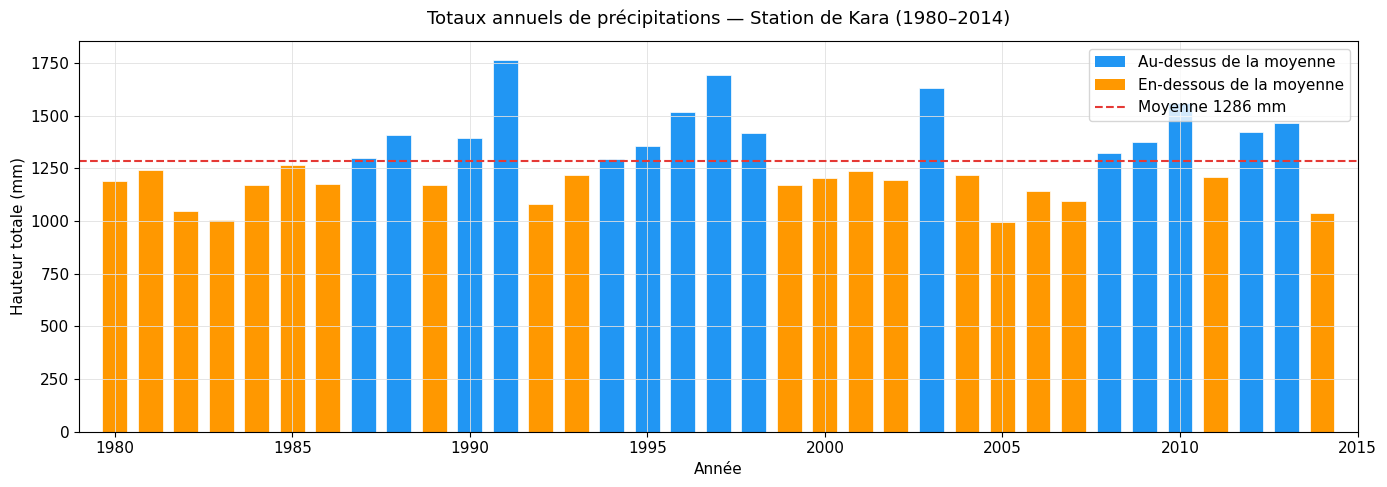

Figure sauvegardée : fig1_totaux_annuels.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

couleurs = ["#2196F3" if v >= moyenne_globale else "#FF9800"
            for v in stats_annuelles["total_annuel"]]

bars = ax.bar(stats_annuelles["annee"], stats_annuelles["total_annuel"],
              color=couleurs, width=0.7, edgecolor="white", linewidth=0.5)

ax.axhline(moyenne_globale, color="#E53935", linestyle="--", linewidth=1.5,
           label=f"Moyenne {moyenne_globale:.0f} mm")

ax.set_title("Totaux annuels de précipitations — Station de Kara (1980–2014)", pad=12)
ax.set_xlabel("Année")
ax.set_ylabel("Hauteur totale (mm)")
ax.set_xlim(1979, 2015)
ax.legend()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Au-dessus de la moyenne"),
    Patch(facecolor="#FF9800", label="En-dessous de la moyenne"),
    plt.Line2D([0],[0], color="#E53935", linestyle="--", label=f"Moyenne {moyenne_globale:.0f} mm")
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig("fig1_totaux_annuels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig1_totaux_annuels.png")


### 6.2 Saisonnalité — pluie moyenne par mois

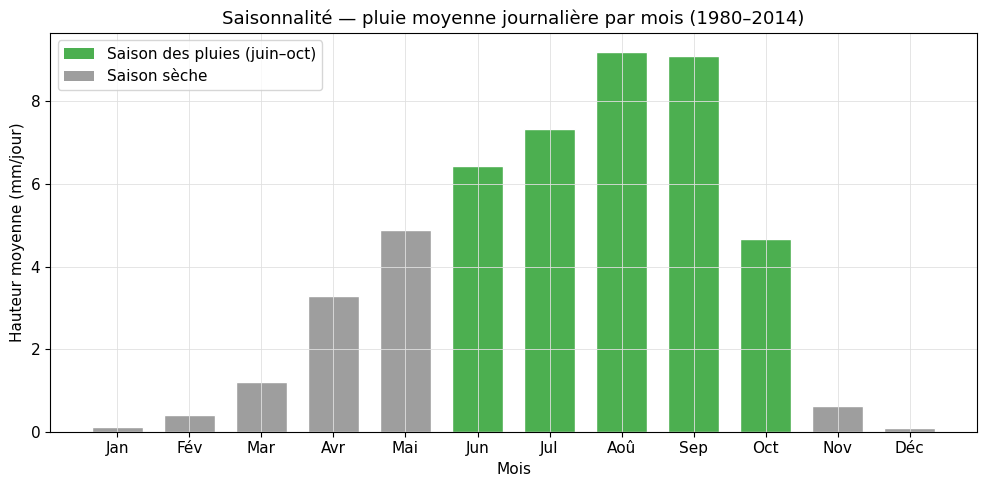

Figure sauvegardée : fig2_saisonnalite.png


In [13]:
stats_mensuelles = (
    df[df["hauteur_mm"].notna()]
    .groupby("mois")["hauteur_mm"]
    .mean()
    .reset_index()
)
stats_mensuelles.columns = ["mois", "hauteur_moy"]

fig, ax = plt.subplots(figsize=(10, 5))

couleurs_mois = ["#4CAF50" if m in [6,7,8,9,10] else "#9E9E9E"
                 for m in stats_mensuelles["mois"]]

ax.bar(stats_mensuelles["mois"], stats_mensuelles["hauteur_moy"],
       color=couleurs_mois, width=0.7, edgecolor="white")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"])
ax.set_title("Saisonnalité — pluie moyenne journalière par mois (1980–2014)")
ax.set_xlabel("Mois")
ax.set_ylabel("Hauteur moyenne (mm/jour)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Saison des pluies (juin–oct)"),
    Patch(facecolor="#9E9E9E", label="Saison sèche"),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("fig2_saisonnalite.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig2_saisonnalite.png")


### 6.3 Distribution des hauteurs journalières

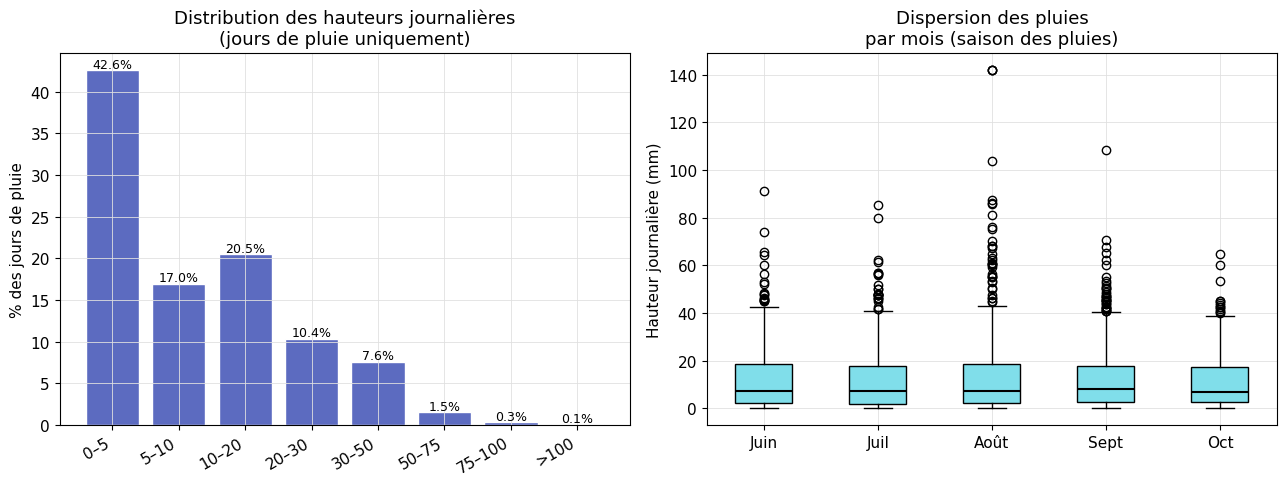

Figure sauvegardée : fig3_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme de distribution
ax1 = axes[0]
tranches = [0, 5, 10, 20, 30, 50, 75, 100, 145]
labels   = ["0–5","5–10","10–20","20–30","30–50","50–75","75–100",">100"]
counts   = pd.cut(jours_pluie["hauteur_mm"], bins=tranches, labels=labels).value_counts().sort_index()
pcts     = counts / len(jours_pluie) * 100

ax1.bar(range(len(labels)), pcts, color="#5C6BC0", edgecolor="white")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_title("Distribution des hauteurs journalières\n(jours de pluie uniquement)")
ax1.set_ylabel("% des jours de pluie")
for i, v in enumerate(pcts):
    ax1.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# Boîte à moustaches par mois (saison des pluies)
ax2 = axes[1]
data_saison = [jours_pluie[jours_pluie["mois"] == m]["hauteur_mm"].values
               for m in [6,7,8,9,10]]
bp = ax2.boxplot(data_saison, patch_artist=True,
                 medianprops=dict(color="black", linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor("#80DEEA")
ax2.set_xticklabels(["Juin","Juil","Août","Sept","Oct"])
ax2.set_title("Dispersion des pluies\npar mois (saison des pluies)")
ax2.set_ylabel("Hauteur journalière (mm)")

plt.tight_layout()
plt.savefig("fig3_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig3_distribution.png")


### 6.4 Nombre de jours de pluie par année

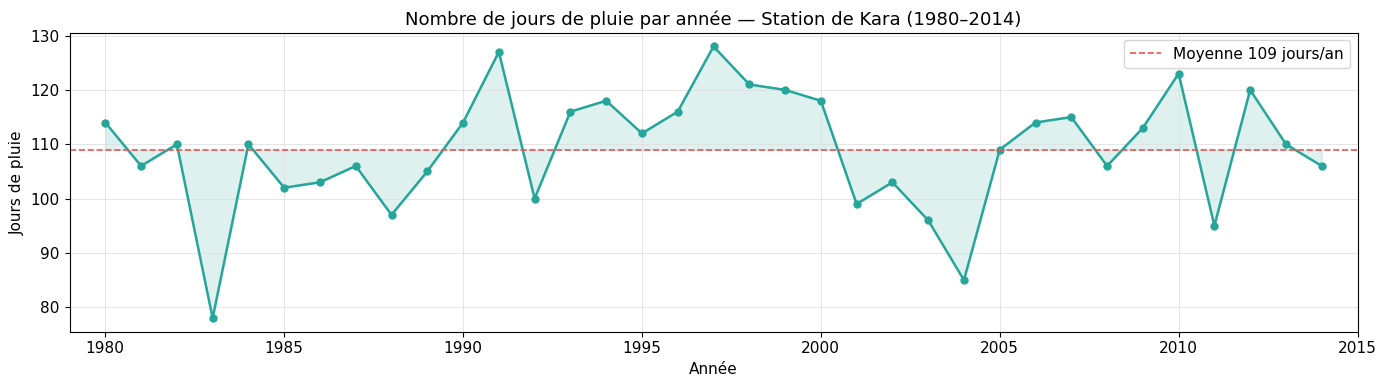

Figure sauvegardée : fig4_jours_pluie.png


In [15]:
fig, ax = plt.subplots(figsize=(14, 4))

moy_jours = stats_annuelles["jours_pluie"].mean()

ax.plot(stats_annuelles["annee"], stats_annuelles["jours_pluie"],
        color="#26A69A", marker="o", markersize=5, linewidth=1.8)
ax.axhline(moy_jours, color="#EF5350", linestyle="--", linewidth=1.2,
           label=f"Moyenne {moy_jours:.0f} jours/an")
ax.fill_between(stats_annuelles["annee"], stats_annuelles["jours_pluie"],
                moy_jours, alpha=0.15, color="#26A69A")

ax.set_title("Nombre de jours de pluie par année — Station de Kara (1980–2014)")
ax.set_xlabel("Année")
ax.set_ylabel("Jours de pluie")
ax.set_xlim(1979, 2015)
ax.legend()

plt.tight_layout()
plt.savefig("fig4_jours_pluie.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig4_jours_pluie.png")


### 6.5 Évolution du maximum journalier annuel

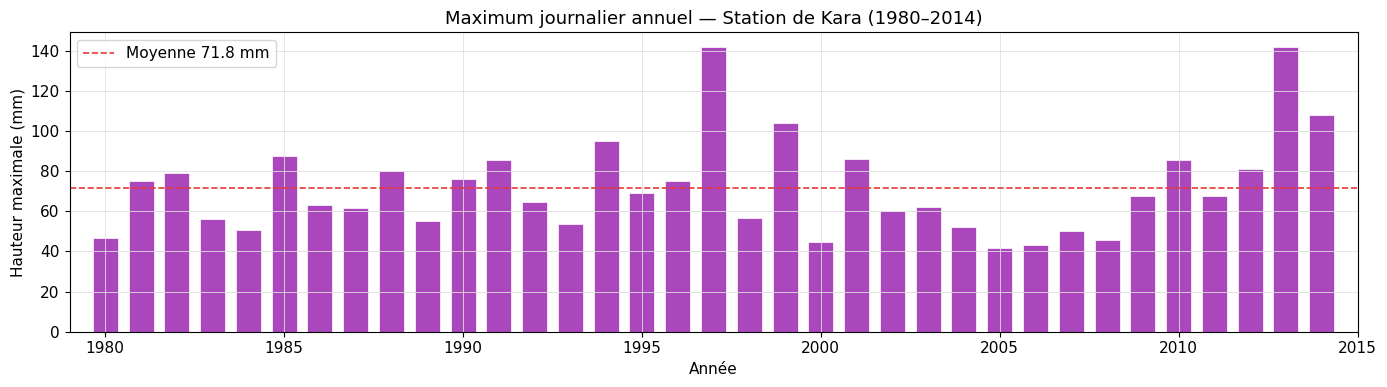

Figure sauvegardée : fig5_max_annuel.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(stats_annuelles["annee"], stats_annuelles["max_journalier"],
       color="#AB47BC", width=0.7, edgecolor="white", linewidth=0.5)
ax.axhline(stats_annuelles["max_journalier"].mean(), color="#E53935",
           linestyle="--", linewidth=1.2,
           label=f"Moyenne {stats_annuelles['max_journalier'].mean():.1f} mm")

ax.set_title("Maximum journalier annuel — Station de Kara (1980–2014)")
ax.set_xlabel("Année")
ax.set_ylabel("Hauteur maximale (mm)")
ax.set_xlim(1979, 2015)
ax.legend()

plt.tight_layout()
plt.savefig("fig5_max_annuel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig5_max_annuel.png")


## 7. Anomalies et points d'attention

In [17]:
print("=== Anomalies détectées lors de l'exploration ===")
print()
print("1. Décalage de colonne pour 2010–2014")
print("   Les blocs 2010–2014 utilisent la colonne 2 pour JOUR")
print("   au lieu de la colonne 1 pour les années précédentes.")
print("   → À corriger dans le Notebook 3 lors de l'extraction propre.")
print()
print("2. Étiquette d'année incorrecte pour 2010 et 2011")
print("   Le fichier brut affiche 'ANNEE 2009 2010' et 'ANNEE 2009 2011'")
print("   Ces blocs correspondent bien à 2010 et 2011 (vérification par continuité).")
print("   → Corrigé dans la carte ANNEE_MARKERS par positionnement manuel.")
print()
print("3. Encodage du zéro")
print("   Années 1980–2009 : zéro = point '.'")
print("   Années 2000–2009 : zéro mixte ('.' ou valeur float 0.0)")
print("   Années 2010–2014 : zéro = NaN (indiscernable d'un jour manquant)")
print("   → La distinction pour 2010–2014 sera gérée dans le Notebook 3")
print("      en s'appuyant sur la saisonnalité (jan-mar et nov-déc = saison sèche).")
print()
print("4. Aucune valeur aberrante isolée détectée")
max_val = df["hauteur_mm"].max()
max_date = df.loc[df["hauteur_mm"].idxmax(), "date"]
print(f"   Le maximum observé ({max_val} mm le {max_date.date()}) est plausible")
print("   pour la région de Kara (événements convectifs intenses en Afrique de l'Ouest).")


=== Anomalies détectées lors de l'exploration ===

1. Décalage de colonne pour 2010–2014
   Les blocs 2010–2014 utilisent la colonne 2 pour JOUR
   au lieu de la colonne 1 pour les années précédentes.
   → À corriger dans le Notebook 3 lors de l'extraction propre.

2. Étiquette d'année incorrecte pour 2010 et 2011
   Le fichier brut affiche 'ANNEE 2009 2010' et 'ANNEE 2009 2011'
   Ces blocs correspondent bien à 2010 et 2011 (vérification par continuité).
   → Corrigé dans la carte ANNEE_MARKERS par positionnement manuel.

3. Encodage du zéro
   Années 1980–2009 : zéro = point '.'
   Années 2000–2009 : zéro mixte ('.' ou valeur float 0.0)
   Années 2010–2014 : zéro = NaN (indiscernable d'un jour manquant)
   → La distinction pour 2010–2014 sera gérée dans le Notebook 3
      en s'appuyant sur la saisonnalité (jan-mar et nov-déc = saison sèche).

4. Aucune valeur aberrante isolée détectée
   Le maximum observé (142.1 mm le 1997-08-05) est plausible
   pour la région de Kara (événements 

## 8. Conclusion de l'exploration

### Ce que nous avons appris

Le fichier `KARA_PLUIE_JOURNALIERE.xls` contient **35 années de données journalières**  
(1980–2014) pour la station de Kara. La série est **globalement complète** :  
aucun bloc annuel manquant, aucune valeur aberrante isolée.

Les chiffres clés confirmés par l'exploration :

| Indicateur | Valeur |
|---|---|
| Période couverte | 1980 – 2014 (35 ans) |
| Moyenne annuelle | ~1 272 mm |
| Année la plus sèche | 1983 (~960 mm) |
| Année la plus humide | 1991 (~1 760 mm) |
| Maximum journalier observé | 142 mm |
| Saison des pluies | Juin – Octobre |

### Ce que le Notebook 3 devra faire

- Résoudre le décalage de colonne pour 2010–2014  
- Distinguer "zéro pluie" de "jour inexistant" pour les années 2010–2014  
- Produire un DataFrame propre au format `(date, hauteur_mm)` exporté en CSV  
- Valider les totaux extraits contre les lignes `TOT.` présentes dans le fichier brut

---
*Fin du Notebook 1 — Exploration brute du pluviomètre*
